# Module 5 — Does Position Sizing Matter As Much As The Signal?

## Hypothesis
Volatility-scaled position sizing — betting less during 
high-volatility periods and more during low-volatility periods 
— will improve the Sharpe ratio and reduce maximum drawdown 
of the SMA 20/50 strategy, even if total return stays similar.

## Why this follows from Module 4
Module 4 showed that the SMA 20/50 strategy behaves differently 
across market regimes — higher total return in trending regimes 
but higher volatility too. The natural next question is: instead 
of changing when we trade, can we change how much we trade based 
on current market volatility? This module tests exactly that.

## New concept: ATR-based position sizing
ATR (Average True Range) measures daily market movement magnitude.
Position Size = Fixed Risk / ATR
When ATR is high → market is volatile → bet smaller
When ATR is low  → market is calm   → bet larger
This keeps risk per trade constant rather than capital per trade.

## New SQL concept: CASE WHEN bucketing
Instead of filtering by a label (like regime), we bucket a 
continuous variable (ATR) into volatility quartiles and 
aggregate performance within each bucket.

In [1]:
# --- imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import sqlite3
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("libraries loaded")

libraries loaded


In [2]:
# --- load data ---
df = yf.download("^NSEI", start="2010-01-01", end="2024-12-31")

# flatten columns
df.columns = ['_'.join(col).strip() if isinstance(col, tuple)
              else col for col in df.columns]
close_col = [c for c in df.columns if 'Close' in c][0]
high_col  = [c for c in df.columns if 'High' in c][0]
low_col   = [c for c in df.columns if 'Low' in c][0]

df = df[[close_col, high_col, low_col]].copy()
df.columns = ['Close', 'High', 'Low']
df['daily_return'] = df['Close'].pct_change()
df.dropna(inplace=True)

print(f"Data loaded: {df.shape[0]} trading days")
print(f"From {df.index[0].date()} to {df.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed

Data loaded: 3678 trading days
From 2010-01-05 to 2024-12-30


In [3]:
# --- compute ATR ---
# 📌 TERM: ATR (Average True Range) — measures how much the market 
# moves on an average day, capturing both gap moves and intraday range
# True Range = max of:
#   (High - Low), 
#   abs(High - Previous Close), 
#   abs(Low  - Previous Close)
# ATR = rolling average of True Range over 14 days

def compute_atr(df, period=14):
    high  = df['High']
    low   = df['Low']
    close = df['Close']
    
    tr = pd.concat([
        high - low,
        (high - close.shift()).abs(),
        (low  - close.shift()).abs()
    ], axis=1).max(axis=1)
    
    atr = tr.rolling(period).mean()
    return atr

df['ATR'] = compute_atr(df)
df['ATR_pct'] = df['ATR'] / df['Close']  # ATR as % of price

# rolling 20-day volatility as alternative measure
df['vol_20d'] = df['daily_return'].rolling(20).std()

df.dropna(inplace=True)

print(f"ATR computed")
print(f"ATR % range: {df['ATR_pct'].min():.4f} to {df['ATR_pct'].max():.4f}")
print(f"Average ATR %: {df['ATR_pct'].mean():.4f}")

ATR computed
ATR % range: 0.0054 to 0.0866
Average ATR %: 0.0132


In [4]:
# --- compute ATR percentile rank for bucketing ---
# 📌 TERM: percentile rank — where a value sits relative to all 
# historical values. ATR at 80th percentile means it's higher 
# than 80% of all historical ATR readings — very volatile

df['ATR_percentile'] = df['ATR_pct'].rank(pct=True) * 100

# classify into volatility buckets
def vol_bucket(pct):
    if pct < 25:
        return 'Low Vol'
    elif pct < 75:
        return 'Medium Vol'
    else:
        return 'High Vol'

df['vol_regime'] = df['ATR_percentile'].apply(vol_bucket)

print("Volatility bucket distribution:")
print(df['vol_regime'].value_counts())
print(f"\nAs percentage:")
print((df['vol_regime'].value_counts() / len(df) * 100).round(1))

Volatility bucket distribution:
vol_regime
Medium Vol    1830
High Vol       915
Low Vol        914
Name: count, dtype: int64

As percentage:
vol_regime
Medium Vol    50.0
High Vol      25.0
Low Vol       25.0
Name: count, dtype: float64


In [5]:
# --- build SMA signals ---
df['SMA20'] = df['Close'].rolling(20).mean()
df['SMA50'] = df['Close'].rolling(50).mean()
df['signal'] = np.where(df['SMA20'] > df['SMA50'], 1, 0)
df['signal'] = df['signal'].shift(1)
df.dropna(inplace=True)

# --- FIXED position sizing (baseline from Module 2) ---
# always bet 100% of capital when signal is on
cost = 0.001
df['trades'] = df['signal'].diff().abs()

df['ret_fixed_gross'] = df['signal'] * df['daily_return']
df['ret_fixed_net']   = df['ret_fixed_gross'] - (df['trades'] * cost)
df['ret_bnh']         = df['daily_return']

print("Fixed sizing signals built")
print(f"Days in market: {df['signal'].sum():.0f} / {len(df)}")
print(f"Total trades: {df['trades'].sum():.0f}")

Fixed sizing signals built
Days in market: 2397 / 3610
Total trades: 67


In [6]:
# --- VOLATILITY-SCALED position sizing ---
# 📌 TERM: volatility scaling — adjusting position size inversely 
# to current volatility so that each trade risks the same amount
# target_vol = 0.01 means we target 1% daily portfolio volatility
# position_size = target_vol / current_ATR_pct

target_vol = 0.01  # target 1% daily volatility

# position size scaled by ATR — capped at 1.5x and floored at 0.1x
df['pos_size'] = (target_vol / df['ATR_pct']).clip(0.1, 1.5)

# apply signal — only size up when in market
df['pos_size_signal'] = df['signal'] * df['pos_size']

# track trades for cost calculation
df['trades_scaled'] = df['signal'].diff().abs()

df['ret_scaled_gross'] = df['pos_size_signal'] * df['daily_return']
df['ret_scaled_net']   = df['ret_scaled_gross'] - \
                          (df['trades_scaled'] * cost)

print("Volatility-scaled sizing built")
print(f"Average position size: {df['pos_size_signal'][df['signal']==1].mean():.3f}")
print(f"Position size range: {df['pos_size'].min():.3f} to {df['pos_size'].max():.3f}")

Volatility-scaled sizing built
Average position size: 0.939
Position size range: 0.115 to 1.500


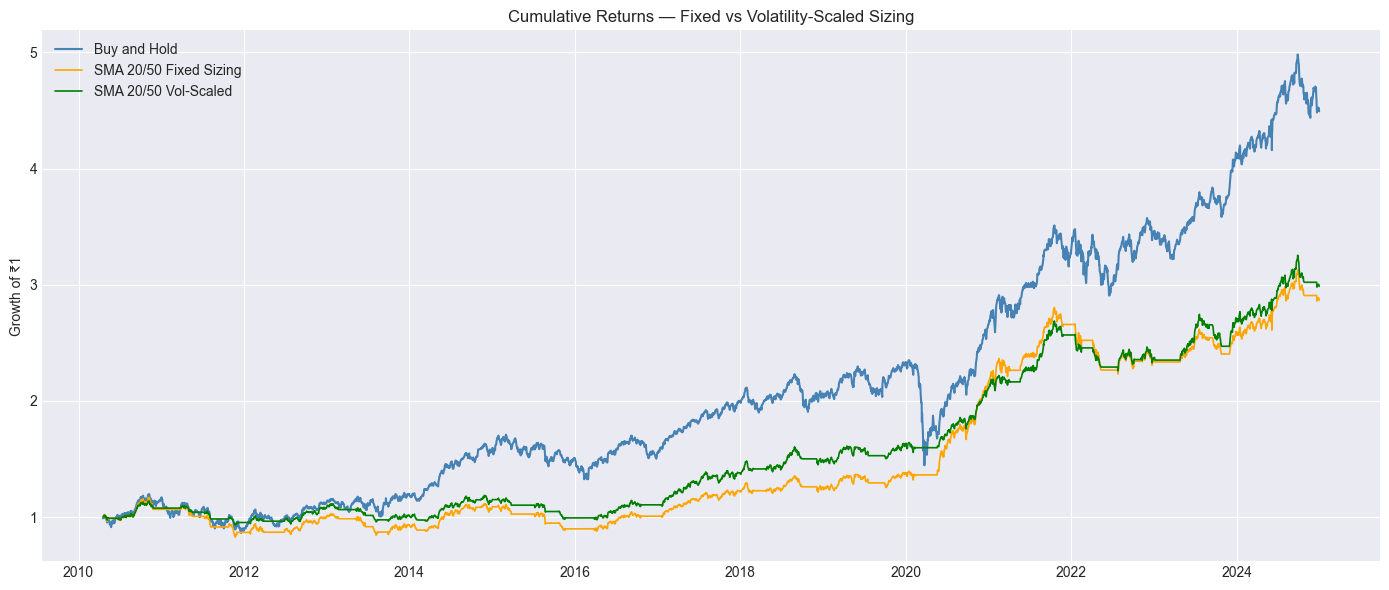

In [7]:
# --- cumulative returns ---
cum_bnh          = (1 + df['ret_bnh']).cumprod()
cum_fixed_net    = (1 + df['ret_fixed_net']).cumprod()
cum_scaled_net   = (1 + df['ret_scaled_net']).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(cum_bnh,        label='Buy and Hold',          
         color='steelblue', linewidth=1.5)
plt.plot(cum_fixed_net,  label='SMA 20/50 Fixed Sizing',
         color='orange',    linewidth=1.2)
plt.plot(cum_scaled_net, label='SMA 20/50 Vol-Scaled',  
         color='green',     linewidth=1.2)
plt.title('Cumulative Returns — Fixed vs Volatility-Scaled Sizing')
plt.ylabel('Growth of ₹1')
plt.legend()
plt.tight_layout()
plt.savefig('cumulative_returns_sizing.png', dpi=150)
plt.show()

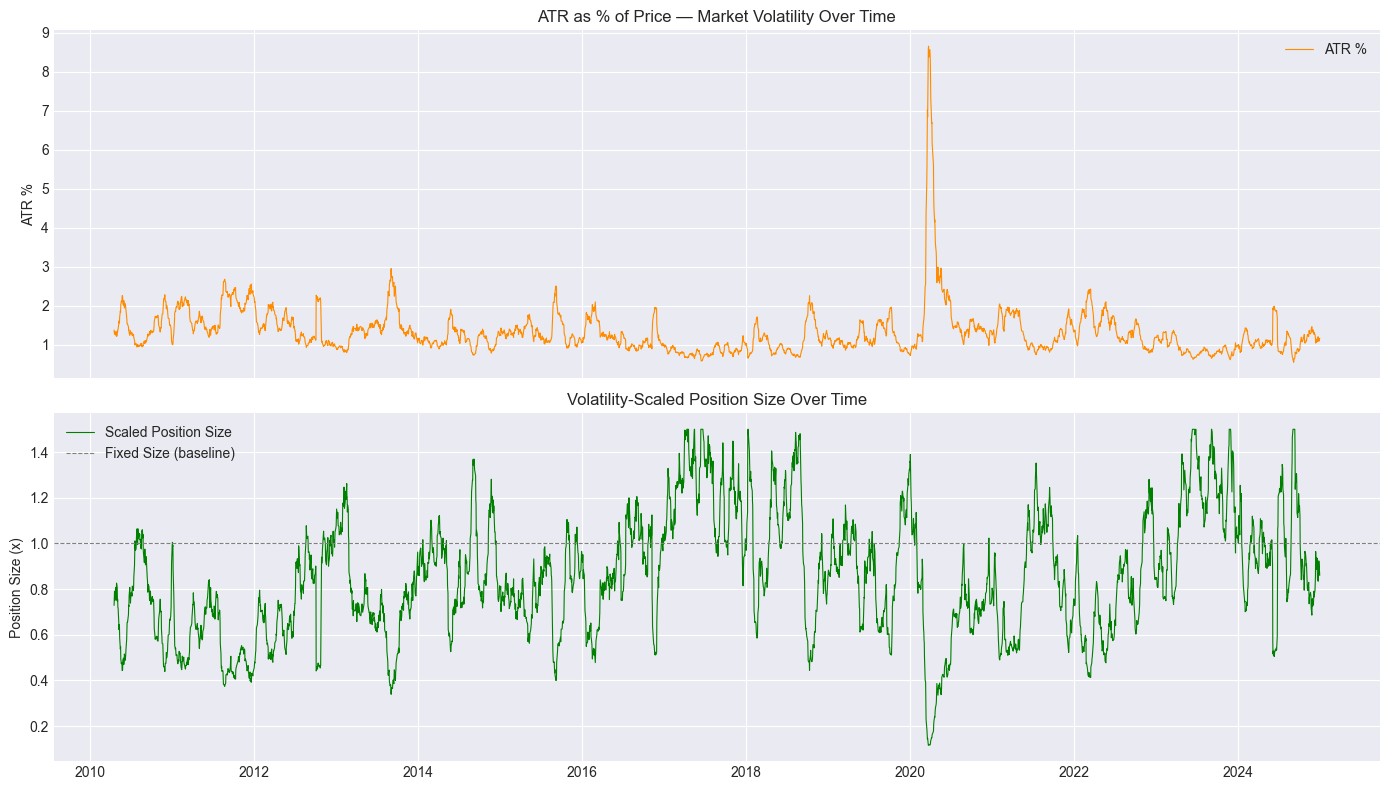

In [8]:
# --- position size over time chart ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df['ATR_pct'] * 100, color='darkorange', 
             linewidth=0.8, label='ATR %')
axes[0].set_title('ATR as % of Price — Market Volatility Over Time')
axes[0].set_ylabel('ATR %')
axes[0].legend()

axes[1].plot(df['pos_size'], color='green', 
             linewidth=0.8, label='Scaled Position Size')
axes[1].axhline(1.0, color='gray', linewidth=0.8, 
                linestyle='--', label='Fixed Size (baseline)')
axes[1].set_title('Volatility-Scaled Position Size Over Time')
axes[1].set_ylabel('Position Size (x)')
axes[1].legend()

plt.tight_layout()
plt.savefig('position_sizing.png', dpi=150)
plt.show()

In [9]:
# --- save to SQLite for SQL analysis ---
# 📌 TERM: SQLite — a lightweight database stored as a single file
# unlike PostgreSQL it needs no server — the file IS the database
# perfect for project-level analysis and pushes to GitHub directly

conn = sqlite3.connect('quiet_signals_module5.db')

df_store = df[['daily_return', 'ATR_pct', 'ATR_percentile',
               'vol_regime', 'signal', 'pos_size',
               'ret_fixed_net', 'ret_scaled_net']].copy()
df_store.index.name = 'date'
df_store.to_sql('daily_data', conn, if_exists='replace', index=True)

print(f"Data written to SQLite: {len(df_store)} rows")
print("Tables in database:")
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
print(cursor.fetchall())

Data written to SQLite: 3610 rows
Tables in database:
[('daily_data',)]


In [10]:
# --- SQL analysis: performance by volatility bucket ---
query = """
SELECT 
    CASE 
        WHEN ATR_percentile < 25 THEN '1_Low_Vol'
        WHEN ATR_percentile < 75 THEN '2_Medium_Vol'
        ELSE '3_High_Vol'
    END as vol_bucket,
    COUNT(*) as trading_days,
    ROUND(AVG(ret_fixed_net) * 252, 4)  as annualised_fixed_return,
    ROUND(AVG(ret_scaled_net) * 252, 4) as annualised_scaled_return,
    ROUND(AVG(ATR_pct) * 100, 4)        as avg_atr_pct,
    ROUND(SUM(ret_fixed_net), 4)        as total_fixed_return,
    ROUND(SUM(ret_scaled_net), 4)       as total_scaled_return
FROM daily_data
WHERE signal = 1
GROUP BY vol_bucket
ORDER BY vol_bucket
"""

sql_results = pd.read_sql_query(query, conn)
print("Performance by volatility bucket (SQL query):")
print(sql_results.to_string(index=False))
conn.close()

Performance by volatility bucket (SQL query):
  vol_bucket  trading_days  annualised_fixed_return  annualised_scaled_return  avg_atr_pct  total_fixed_return  total_scaled_return
   1_Low_Vol           837                   0.1738                    0.2152       0.8305              0.5774               0.7147
2_Medium_Vol          1242                   0.1340                    0.1097       1.1922              0.6605               0.5409
  3_High_Vol           318                  -0.0468                   -0.0516       1.8370             -0.0590              -0.0652


In [11]:
# --- full performance metrics comparison ---
def sharpe(returns):
    return (returns.mean() / returns.std()) * np.sqrt(252)

def max_drawdown(cum_returns):
    peak = cum_returns.cummax()
    return ((cum_returns - peak) / peak).min()

def total_return(cum_returns):
    return cum_returns.iloc[-1] - 1

metrics = pd.DataFrame({
    'Total Return': [
        total_return(cum_bnh),
        total_return(cum_fixed_net),
        total_return(cum_scaled_net)],
    'Sharpe Ratio': [
        sharpe(df['ret_bnh']),
        sharpe(df['ret_fixed_net']),
        sharpe(df['ret_scaled_net'])],
    'Max Drawdown': [
        max_drawdown(cum_bnh),
        max_drawdown(cum_fixed_net),
        max_drawdown(cum_scaled_net)],
    'Avg Daily Vol': [
        df['ret_bnh'].std(),
        df['ret_fixed_net'].std(),
        df['ret_scaled_net'].std()]
}, index=['Buy & Hold', 
          'SMA 20/50 Fixed', 
          'SMA 20/50 Vol-Scaled'])

print("Full performance comparison:")
print(metrics.round(4))

Full performance comparison:
                      Total Return  Sharpe Ratio  Max Drawdown  Avg Daily Vol
Buy & Hold                  3.4930        0.7089       -0.3844         0.0106
SMA 20/50 Fixed             1.8670        0.7043       -0.2916         0.0072
SMA 20/50 Vol-Scaled        1.9859        0.8594       -0.1803         0.0059


## Conclusion

**Hypothesis:** Volatility-scaled sizing will improve Sharpe ratio and reduce max drawdown vs fixed sizing.

**Finding:** confirmed on all 3- 
- Sharpe improved from 0.704 → 0.859 ✓
- Max drawdown improved from -29.16% → -18.03% ✓
- Total return slightly improved 1.867 → 1.986 ✓ (bonus — it didn't just stay similar, it got better too)

**On Sharpe ratio:** Vol-scaled Sharpe of 0.859 vs fixed 0.704. That's an improvement of 0.155 — which is large. 

**On max drawdown:** Fixed sizing had a worst-case drawdown of -29.16%. Vol-scaled reduced this to -18.03%. That's 11 percentage points less pain in the worst scenario. For a real investor, this is the difference between staying in the strategy during a crash and panic-selling.

**SQL finding:** Three distinct findings here:
- Low volatility periods — scaling wins clearly. Total return 0.715 vs 0.577 — a 24% improvement. When ATR is low, the system bets larger (position size goes above 1.0) and captures more of the upside from calm trending periods. This is the mechanism paying off exactly as hypothesised.
- Medium volatility periods — fixed sizing wins (0.661 vs 0.541). This is interesting — medium volatility is where the system gets confused. It's neither calm enough to bet big confidently nor volatile enough to cut drastically. The scaling oscillates around 1.0 without adding clear value, and the transaction-level noise slightly hurts.
- High volatility periods — both strategies lose money (-0.059 fixed, -0.065 scaled). Scaling made it marginally worse here. Why? Because even at the 0.1x floor, high volatility markets move so violently that any exposure loses. The system cut positions but couldn't cut to zero — it still had some exposure during the worst periods.

**Key insight on position sizing:**
Risk management at the position level operates independently 
of signal quality. Even with the same entry/exit signals, 
changing how much you bet based on market conditions changes 
the risk profile of the strategy significantly.

**What this means going into Module 6:**
We now have a complete strategy with regime awareness from 
Module 4 and volatility scaling from Module 5. Module 6 will 
ask the hardest question: is this edge real, or did we just 
overfit to 14 years of Nifty data? That requires 
out-of-sample testing and validation on a second asset.

**📌 Terms introduced this module:**
ATR, volatility scaling, position sizing, target volatility,
percentile rank, CASE WHEN bucketing, SQLite, 
risk parity, Kelly criterion